In [122]:
# Add import 
import sys
import torch 
from torch import nn
from torch import optim
import tqdm
import numpy as np
import matplotlib.pyplot as plt
# allow reload of python modules
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [123]:
TORCH_USE_CUDA_DSA=1

In [124]:
def force_cudnn_initialization():
    s = 32
    dev = torch.device('cuda')
    torch.nn.functional.conv2d(torch.zeros(s, s, s, s, device=dev), torch.zeros(s, s, s, s, device=dev))

In [125]:
force_cudnn_initialization()

# Hyperparams Constants

In [126]:
normalizer = MinMaxFeatureNormalizer()
CONFIG = {
    # Model configuration
    'representation_dim': 32,
    # Hyperparameters for training
    'batch_size': 32,
    'num_epochs': 100,
    'learning_rate': 0.001,
    'optimizer': optim.Adam,
    # Hyperparameters for diffusion process
    'noise_steps': 100,
    'normalize': True,
    'normalizer':normalizer,
    'scheduler': optim.lr_scheduler.ExponentialLR,
    'ema': EMA(0.99),
    'scheduler_gamma': 0.999,

    # Dataset specific configuration
    'n_paths_per_world': 1000,
    'n_worlds': 100,
}

# Dataloader

In [127]:
from dataset import RobotPathDataset

In [128]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
device

cuda:0


device(type='cuda', index=0)

### Normalizer

In [129]:
file = 'D:\Desktop\ADLR\RobotPathData\data\SingleSphere02_all.db'
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'], normalize=True, normalizer=normalizer)
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples')
indx_sample = 5
sample = dataset[indx_sample]

data shape: torch.Size([100000, 20, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0')
 sample shape torch.Size([20, 2]) with 100000 samples


In [130]:

np.unique(dataset.worlds_indx)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60], dtype=int64)

In [131]:
sample

{'path': tensor([[-0.9497,  0.9509],
         [-0.7960,  0.8031],
         [-0.6443,  0.6532],
         [-0.4886,  0.5074],
         [-0.3389,  0.3556],
         [-0.1827,  0.2108],
         [-0.0346,  0.0580],
         [ 0.1215, -0.0868],
         [ 0.2556, -0.2397],
         [ 0.3615, -0.4005],
         [ 0.4699, -0.5533],
         [ 0.5811, -0.7141],
         [ 0.4582, -0.8485],
         [ 0.2630, -0.8550],
         [ 0.0798, -0.8534],
         [-0.1037, -0.8156],
         [-0.2944, -0.7874],
         [-0.4928, -0.7882],
         [-0.6863, -0.7836],
         [-0.8824, -0.7817]], device='cuda:0'),
 'world_indx': 0,
 'world_img': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]])}

In [132]:
denormalized_sample = normalizer.denormalize(sample['path'])
denormalized_sample

tensor([[0.2515, 9.7543],
        [1.0200, 9.0153],
        [1.7786, 8.2662],
        [2.5571, 7.5371],
        [3.3056, 6.7780],
        [4.0863, 6.0539],
        [4.8270, 5.2899],
        [5.6077, 4.5658],
        [6.2782, 3.8017],
        [6.8073, 2.9977],
        [7.3497, 2.2336],
        [7.9055, 1.4295],
        [7.2908, 0.7573],
        [6.3151, 0.7251],
        [5.3991, 0.7328],
        [4.4816, 0.9218],
        [3.5279, 1.0629],
        [2.5358, 1.0592],
        [1.5685, 1.0821],
        [0.5882, 1.0917]], device='cuda:0')

In [133]:
WORLD_IMG = sample['world_img'] 

In [135]:
from torch.utils.data import DataLoader
batch_size = CONFIG['batch_size']
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)
# iterate over the dataset
# get the first batch
sample_batch = next(iter(dataloader))


In [136]:
sample_batch['world_indx'].shape

torch.Size([32])

# Archtechture

### encoder

In [137]:
from model import WorldIndexEmbeder

In [138]:
embedding_dim = CONFIG['representation_dim']
# Define the model
encoder = WorldIndexEmbeder(num_embeddings=CONFIG['n_worlds'], embedding_dim=CONFIG['representation_dim']).to(device)

### Model and diffusion

In [139]:
from model import Diffusion, TemporalUnet

In [140]:
# Create the UNet
transition_dim = sample['path'].shape[-1] # transition_dim is the dimension the model should predict. not the timesteps
model = TemporalUnet(horizon=20, transition_dim=transition_dim, dim=CONFIG['representation_dim'], encoder=encoder, device=device)

[ models/temporal ] Channel dimensions: [(2, 16), (16, 32), (32, 64)]
[(2, 16), (16, 32), (32, 64)]


In [141]:
model.to(device);
model.device

device(type='cuda', index=0)

In [142]:
# create the diffusion model
diffusion = Diffusion(input_shape=sample['path'].shape, noise_steps=CONFIG['noise_steps'], device=device)

In [143]:
# test the model
x = sample_batch
timesteps = diffusion.sample_timesteps(batch_size)
y = model(x['path'], timesteps)
y.shape
assert y.shape == (batch_size, 20, 2)

In [144]:
# noise input 
timesteps = diffusion.sample_timesteps(batch_size)
x_t, noise = diffusion.noise_input(sample_batch['path'],timesteps)
x_t.shape, noise.shape

(torch.Size([32, 20, 2]), torch.Size([32, 20, 2]))

In [145]:
import matplotlib.cm as cm

number_of_samples_to_show = 5
# test the model
x = sample_batch['path'][0:number_of_samples_to_show]
timesteps = diffusion.sample_timesteps(number_of_samples_to_show)
y = model(x, timesteps)
# noise input 
timesteps = diffusion.sample_timesteps(number_of_samples_to_show)
x_t, noise = diffusion.noise_input(x,timesteps)
x_t.shape, noise.shape
# plot sample entire batch
colors = cm.rainbow(np.linspace(0, 1, len(x)))
def visualize_diffusion_process(x, x_t, normalizer=None):
    if normalizer:
        x = normalizer.denormalize(x)
        x_t = normalizer.denormalize(x_t)
    x = x.cpu().detach().numpy()
    x_t = x_t.cpu().detach().numpy()
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    for i in range(number_of_samples_to_show):
        ax.plot(x[i, :, 0], x[i, :, 1], 'o-', label='input', color=colors[i])
        ax.plot(x_t[i, :, 0], x_t[i, :, 1], 'o-', label=f'noise t={timesteps[i]}', color=colors[i], alpha=0.5)
    plt.legend()
    plt.show()

print(timesteps)
# visualize_diffusion_process(x, x_t, normalizer=normalizer)
# visualize_diffusion_process(x, x_t, normalizer=None)


tensor([17, 54, 13, 26, 67], device='cuda:0')


# Training

In [146]:
# write training loop 
import torch.optim as optim
import torch.nn as nn


In [147]:
from LoggingManager import LoggingManager
logging_manager = LoggingManager(experiement_name='path-dataset-multiworld')
logging_manager.log_config(CONFIG);

INFO:LoggingManager:Configuration:
INFO:LoggingManager:representation_dim: 16
INFO:LoggingManager:batch_size: 32
INFO:LoggingManager:num_epochs: 100
INFO:LoggingManager:learning_rate: 0.001
INFO:LoggingManager:optimizer: <class 'torch.optim.adam.Adam'>
INFO:LoggingManager:noise_steps: 100
INFO:LoggingManager:normalize: True
INFO:LoggingManager:normalizer: <dataset.RobotPathDataset.normalizer.MinMaxFeatureNormalizer object at 0x000001B43A1C35B0>
INFO:LoggingManager:scheduler: <class 'torch.optim.lr_scheduler.ExponentialLR'>
INFO:LoggingManager:ema: <model.models.EMA object at 0x000001B43A1C2F20>
INFO:LoggingManager:scheduler_gamma: 0.999
INFO:LoggingManager:n_paths_per_world: 1000
INFO:LoggingManager:n_worlds: 100


Logging to logs\path-dataset-multiworld/21h-34m-13-05-2024/logs.log


### Set up validation and plotting function

In [148]:
def plot_diffusions(intermediates, world_imgs=None, normalizer=None, max_plots=8):
    # choose 5 intermediates equally spaced with the last one being at the end indexand 
    intermediates_indx_to_draw = [0, len(intermediates) //4 ,len(intermediates)//2, (3* len(intermediates) ) // 4,len(intermediates)-1]
    if normalizer:
        intermediates = normalizer.denormalize(intermediates, is_numpy=True)
    intermediates = intermediates[intermediates_indx_to_draw]
    intermediates = intermediates.transpose(1,0,2,3)
    if intermediates.shape[0] > max_plots:
        intermediates = intermediates[:max_plots]
    number_of_samples = intermediates.shape[0]
    number_of_steps = intermediates.shape[1]
    fig , ax = plt.subplots(number_of_samples,number_of_steps, figsize=(20,20))
    for i, sample in enumerate(intermediates):
        for j, step in enumerate(sample): 
            ax[i, j].plot(step[:, 0], step[:, 1], 'o-', label='l', color='red', alpha=0.8)
            if world_imgs is not None:
                ax[i, j].imshow(world_imgs[i].T, extent=[-0.8, 10.2, -0.8, 10.2], origin='lower', cmap='binary')
             # put 1st point in green and last point in red
            ax[i, j].plot(step[0, 0], step[0, 1], 'o-', label='start', color='green')
            ax[i, j].plot(step[-1, 0], step[-1, 1], 'o-', label='end', color='yellow')
    plt.tight_layout()
    return fig

# plot = plot_diffusions(intermediates, world_img=WORLD_IMG)
# logging_manager.tb_log_figure(plot, 'diffusion_samples')

In [149]:
def plot_noise_and_predicted_noise(sample, noise, predicted_noise, timesteps, normalizer=None, max_plots=8):

    # if any of the inputs are in the GPU move them to CPU
    if sample.is_cuda:
        sample = sample.clone().cpu().detach().numpy()
    if noise.is_cuda:
        noise = noise.clone().cpu().detach().numpy()
    if predicted_noise.is_cuda:
        predicted_noise = predicted_noise.clone().cpu().detach().numpy()
    if timesteps.is_cuda:
        timesteps = timesteps.clone().cpu().detach().numpy()

    # get per sample differnce betwen noise and predicted noise MSE
    mse_per_sample = np.mean(np.square(noise - predicted_noise), axis=(1, 2))
    sample_plus_noise = sample + noise
    sample_plus_predicted_noise = sample + predicted_noise
    # denormalize the samples
    if normalizer:
        sample = normalizer.denormalize(sample, is_numpy=True)
        sample_plus_noise = normalizer.denormalize(sample_plus_noise, is_numpy=True)
        sample_plus_predicted_noise = normalizer.denormalize(sample_plus_predicted_noise, is_numpy=True)
    if sample.shape[0] > max_plots:
        sample = sample[:max_plots]
        sample_plus_noise = sample_plus_noise[:max_plots]
        sample_plus_predicted_noise = sample_plus_predicted_noise[:max_plots]
        mse_per_sample = mse_per_sample[:max_plots]
        timesteps = timesteps[:max_plots]
    n_cols = 2
    n_rows = sample.shape[0] // n_cols 
    fig, ax = plt.subplots(n_rows , n_cols, figsize=(20, 20))
    for i in range(n_rows):
        for j in range(n_cols):
            ax[i, j].plot(sample[j*n_cols + i, :, 0], sample[j*n_cols + i, :, 1], 'o-', label='input', color='blue')
            ax[i, j].plot(sample_plus_noise[j*n_cols + i, :, 0], sample_plus_noise[j*n_cols + i, :, 1], 'o-', label=f'noised', color='green', alpha=0.5)
            ax[i, j].plot(sample_plus_predicted_noise[j*n_cols + i, :, 0], sample_plus_predicted_noise[j*n_cols + i, :, 1], 'o-', label=f'predicted', color='red', alpha=0.5)
            ax[i, j].set_title(f'MSE={mse_per_sample[j*n_cols + i]:.3f}, t={timesteps[j*n_cols + i]}')  # Title for each subplot

    plt.legend()
    return fig


# Train 

In [150]:
START_FROM_CHECKPOINT = True
Checkpoint_file = r"D:\Desktop\ADLR\RobotPathData\logs\path-dataset-multiworld\21h-10m-13-05-2024\model-epoch_0-loss_0.259-time_21h-14m-13-05-2024"


In [151]:
# train the model

import random


optimizer = CONFIG['optimizer'](model.parameters(), lr=CONFIG['learning_rate'])
scheduler = CONFIG['scheduler'](optimizer, gamma=CONFIG['scheduler_gamma'])
ema = CONFIG['ema']
ema_model = copy.deepcopy(model).eval().requires_grad_(False)

# Restart from checkpoint 
if START_FROM_CHECKPOINT:
    model, optimizer, scheduler, epoch, loss = logging_manager.load_checkpoint(model, optimizer, scheduler, filename=Checkpoint_file)
    ema.step_ema(ema_model,model)
    logging_manager.log_message(f'Restarting from epoch {epoch} with loss {loss}')

for epoch in range(CONFIG['num_epochs']):
    pbar = tqdm.tqdm(dataloader, total=len(dataloader))
    running_loss = 0.0
    # iterate over the dataset
    for i, batch_and_info in enumerate(pbar):
        batch, batch_world_indx, batch_world_img = batch_and_info['path'], batch_and_info['world_indx'], batch_and_info['world_img']
        
        # Training step
        model.train()
        optimizer.zero_grad()
        x = batch.to(device)
        cond = batch_world_indx.to(device)
        # preturb input. add noise to it
        timesteps_choosen = diffusion.sample_timesteps(x.shape[0])
        x_t, noise = diffusion.noise_input(x,timesteps_choosen)
        # get model to predict the noise
        pred_noise = model(x_t, timesteps_choosen, cond)
        
        # print the encoder weights to make sure it is training 

        loss = nn.MSELoss()(noise, pred_noise)
        loss.backward()
        optimizer.step()
        # update the EMA model
        ema.step_ema(ema_model,model)
        running_loss += loss.item()
        logging_manager.plot_losses(loss.item())
        
        pbar.set_postfix({'loss': loss.item()})
        if i % 1000 == 0:

            # plot noise and predicted noise
            plot = plot_noise_and_predicted_noise(x, noise, pred_noise, timesteps_choosen, normalizer=CONFIG['normalizer'])
            logging_manager.tb_log_figure(plot, 'noise_and_predicted_noise', step= i + epoch * len(dataloader))

            # plot noise and predicted noise ema
            ema_model.eval()
            pred_noise_ema = ema_model(x_t, timesteps_choosen)
            plot = plot_noise_and_predicted_noise(x, noise, pred_noise_ema, timesteps_choosen, normalizer=CONFIG['normalizer'])
            logging_manager.tb_log_figure(plot, 'ema_noise_and_predicted_noise', step= i + epoch * len(dataloader))
                    
    logging_manager.log_message(f'Epoch {epoch} Epoch loss: {running_loss/len(dataloader)}')
    # scheduler
    scheduler.step()
    running_loss = 0.0
    # Validation 
    model.eval()


    if epoch% 1 == 0:
        logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss)  
        # sample model
        samples, intermediates = diffusion.sample(model,5)
        random_world_indx= torch.randint(0, CONFIG['n_worlds'], (1,), device=device)
        random_world_img = dataset.world_image_from_world_indx(random_world_indx)
        plot = plot_diffusions(intermediates,  normalizer=CONFIG['normalizer'])
        logging_manager.tb_log_figure(plot, 'diffusion_samples', step=epoch) 
        # sample ema model
        samples, intermediates = diffusion.sample(ema_model,5)
        plot = plot_diffusions(intermediates, normalizer=CONFIG['normalizer'])
        logging_manager.tb_log_figure(plot, 'diffusion_samples_ema', step=epoch)
        logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss)# create constraints dict 
        for k in range(2):
            constraints = {
                0: torch.tensor([0, 0], device=device),
                19: torch.tensor([9, 9],device=device),
            }
            n=CONFIG['batch_size']
            cond = batch_world_indx.to(device)
            world_imgs = batch_world_img
            logging_manager.log_message(f'Generating samples from edge to edge with worlds {cond}')
            samples, intermediates = diffusion.sample_with_constraints(model, n=n, constraints=constraints, cond=cond,normalizer=CONFIG['normalizer'])
            plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer'])
            logging_manager.tb_log_figure(plot, f'samples edge to edge World {k}', step=epoch)

         

INFO:LoggingManager:Checkpoint loaded from D:\Desktop\ADLR\RobotPathData\logs\path-dataset-multiworld\21h-10m-13-05-2024\model-epoch_0-loss_0.259-time_21h-14m-13-05-2024
INFO:LoggingManager:Restarting from epoch 0 with loss 0.25919991731643677
100%|██████████| 3125/3125 [03:48<00:00, 13.69it/s, loss=0.196]
INFO:LoggingManager:Epoch 0 Epoch loss: 0.23983206350326539
INFO:LoggingManager:Checkpoint saved to logs\path-dataset-multiworld/21h-34m-13-05-2024\model-epoch_0-loss_0.196-time_21h-38m-13-05-2024
99it [00:01, 54.44it/s]
99it [00:01, 55.02it/s]
INFO:LoggingManager:Checkpoint saved to logs\path-dataset-multiworld/21h-34m-13-05-2024\model-epoch_0-loss_0.196-time_21h-38m-13-05-2024
INFO:LoggingManager:Generating samples from edge to edge with worlds tensor([58, 54, 55,  2, 45, 35, 57, 41, 29, 60, 10, 49, 11, 45, 35, 45, 38, 45,
        15, 11,  4, 30, 36,  5, 36, 53, 21,  2, 48, 46, 26, 42],
       device='cuda:0')
99it [00:01, 53.70it/s]
INFO:LoggingManager:Generating samples from edge

KeyboardInterrupt: 

In [ ]:
batch_world_indx.shape
r = torch.ones_like(batch_world_indx, device=device) * 8
r

tensor([8, 8, 8, 8, 8, 8, 8, 8], device='cuda:0')

In [ ]:
samples, intermediates = diffusion.sample(model,8, cond=r)

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
constraints = {
    0: torch.tensor([0, 0], device=device),
    19: torch.tensor([9, 9],device=device),
}
# choose 1 random world
random_world_indx= 5
# sample n samples from this world
n=5
cond = torch.from_numpy(np.full((n,), random_world_indx)).to(device)
samples, intermediates = diffusion.sample_with_constraints(model, n=n, constraints=constraints,normalizer=CONFIG['normalizer'], cond=cond)
plot = plot_diffusions(intermediates, world_img=WORLD_IMG, normalizer=CONFIG['normalizer'])
logging_manager.tb_log_figure(plot, f'samples edge to edge World {k}', step=epoch)

0it [00:00, ?it/s]


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss)

In [ ]:
# # Save final model
torch.save(model.state_dict(), 'model.pth')

# Sample Model

In [ ]:
# load checkpoint
model, _, _, _, _, = logging_manager.load_checkpoint(model, optimizer, scheduler, filename=r'D:\Desktop\ADLR\RobotPathData\logs\dummy-path-dataset\14h-36m-11-05-2024\model-epoch_39-loss_0.121-time_16h-48m-11-05-2024')

99it [00:01, 50.69it/s]


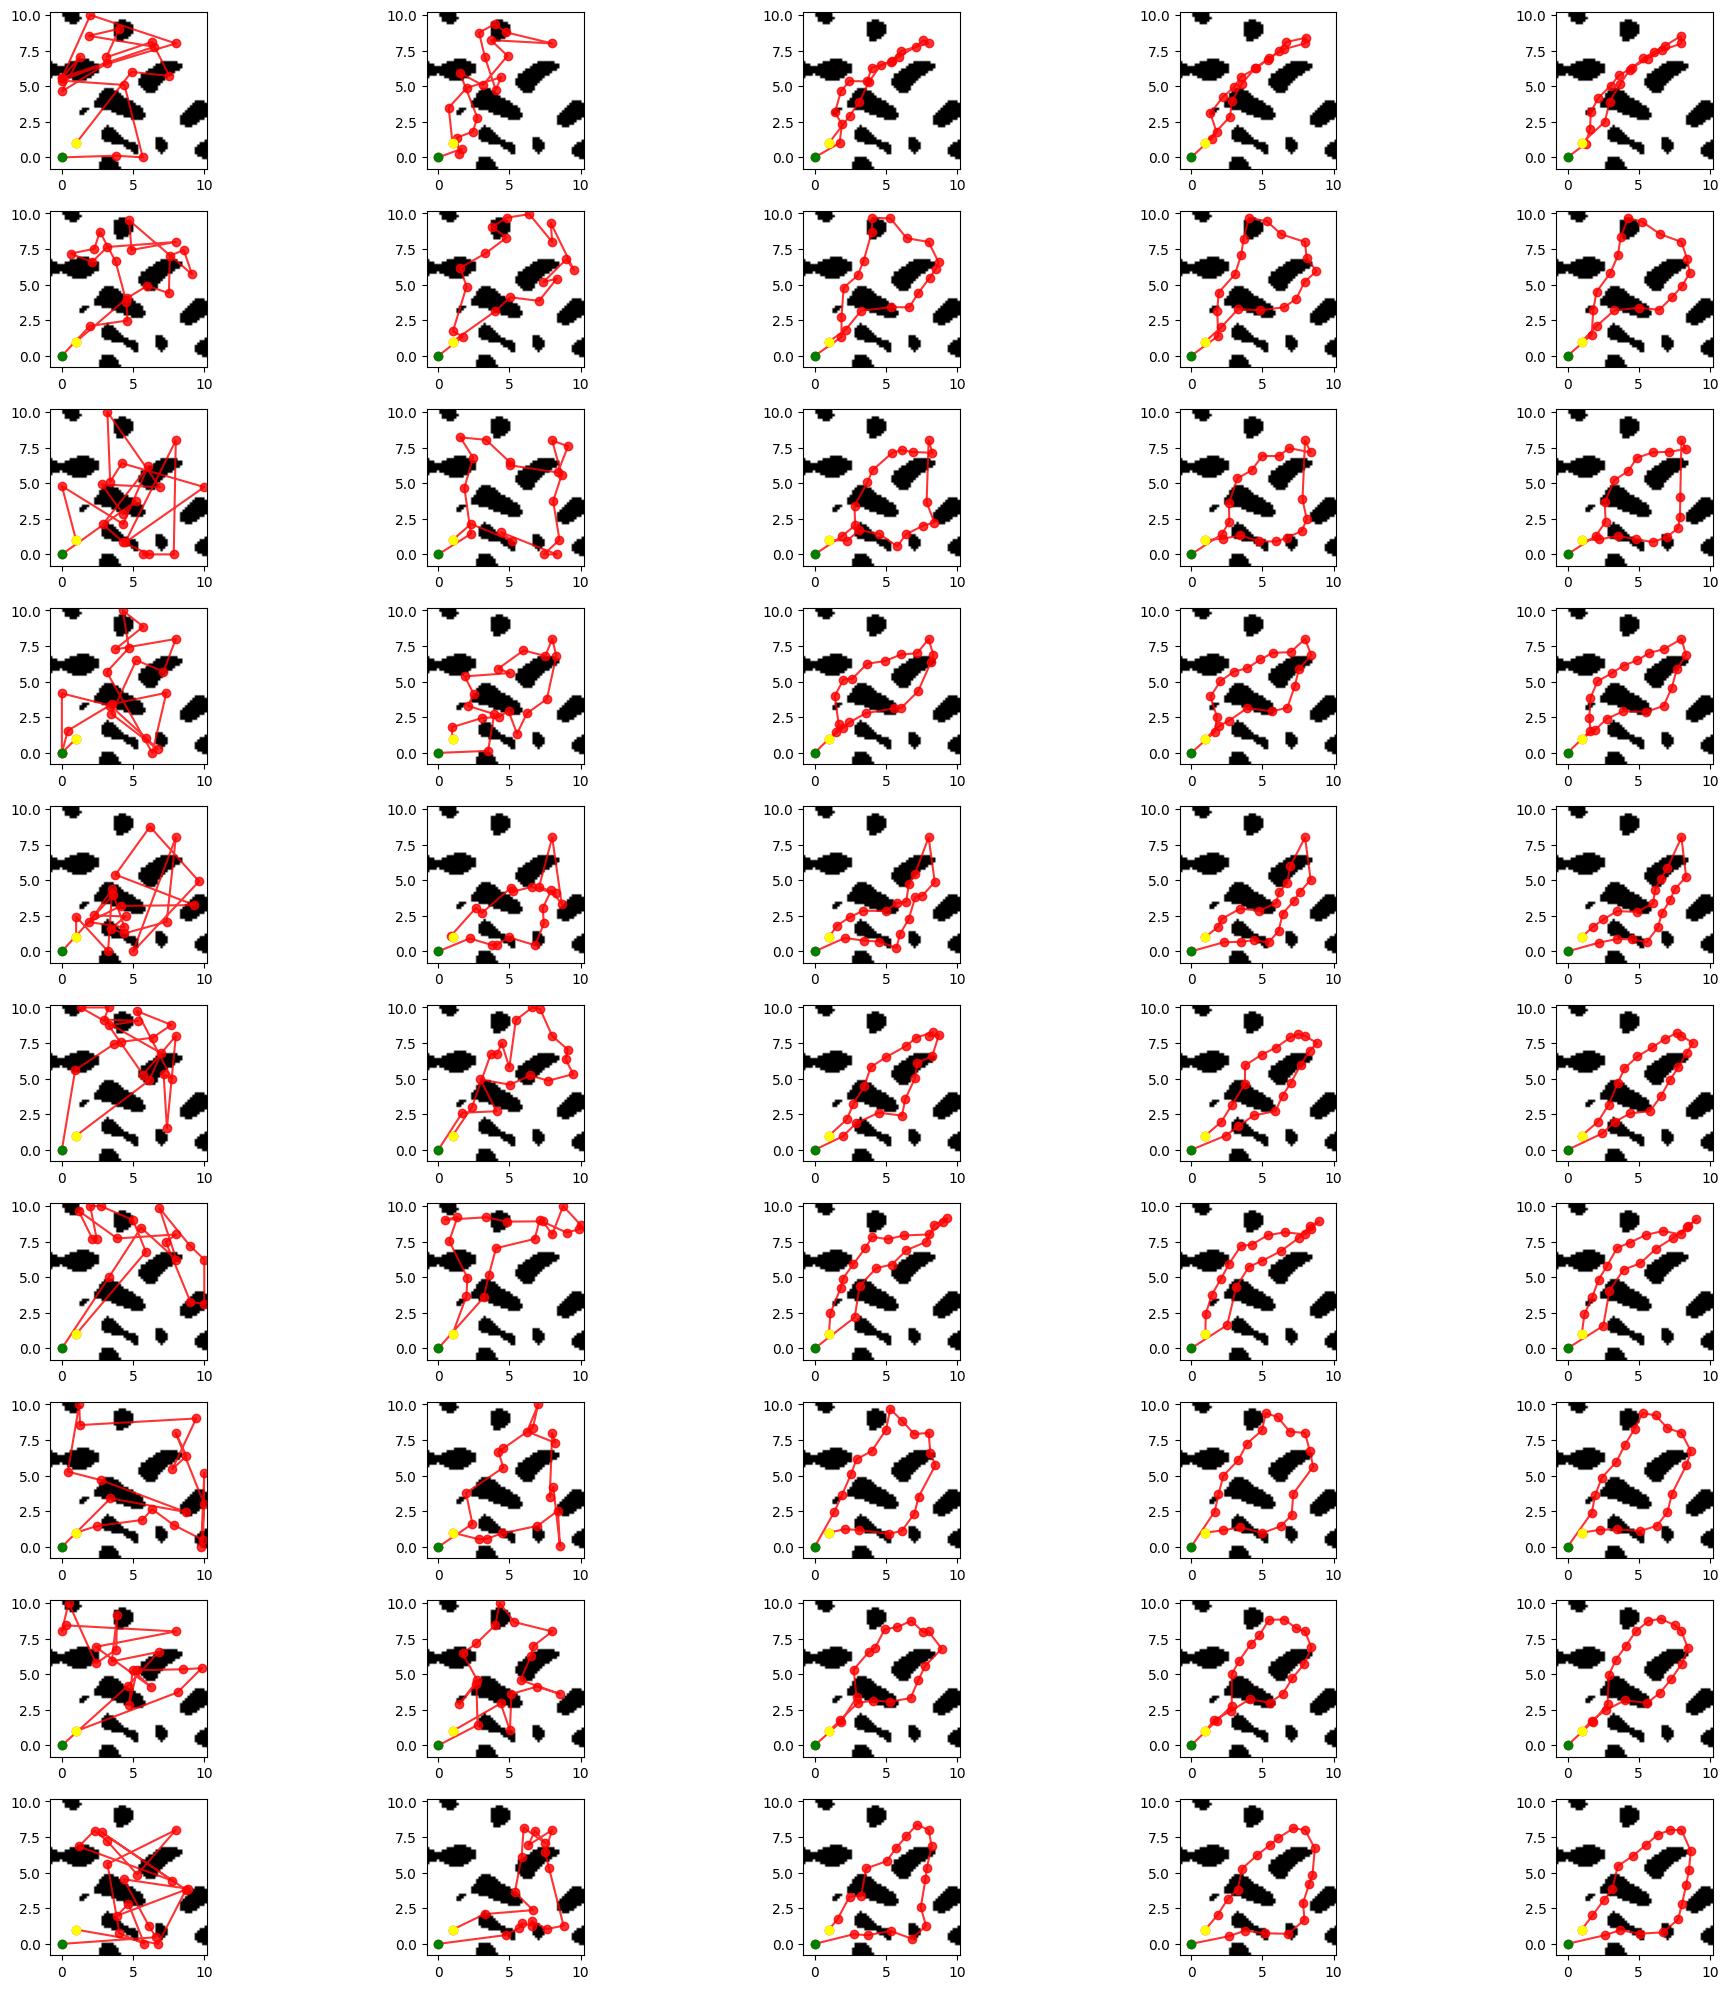

In [ ]:
# create constraints dict 
constraints = {
    0: torch.tensor([0, 0], device=device),
    10: torch.tensor([8, 8],device=device),
    19: torch.tensor([1, 1],device=device),
}
# sample from final model
samples, intermediates = diffusion.sample_with_constraints(model, 10, constraints, normalizer=CONFIG['normalizer'])
plot = plot_diffusions(intermediates, world_img=WORLD_IMG, normalizer=CONFIG['normalizer'])